In [13]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


In [14]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


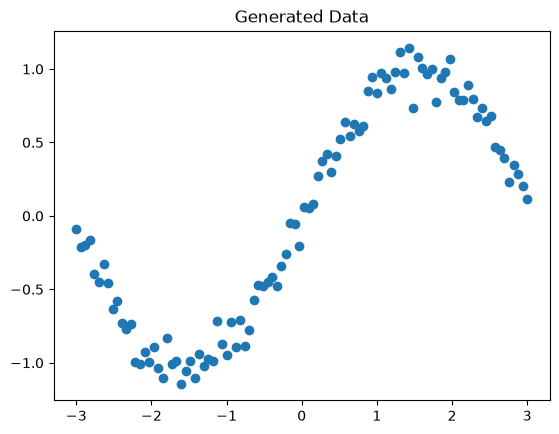

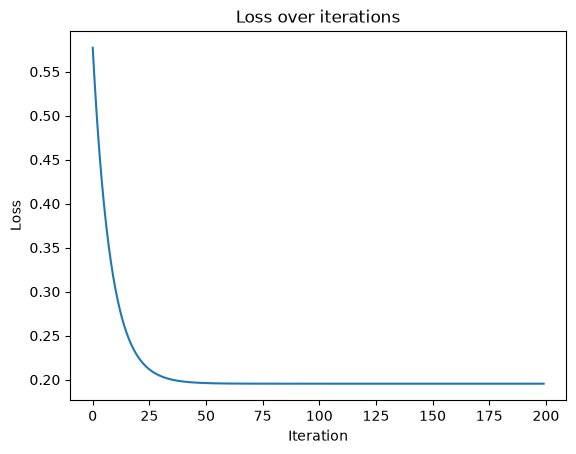

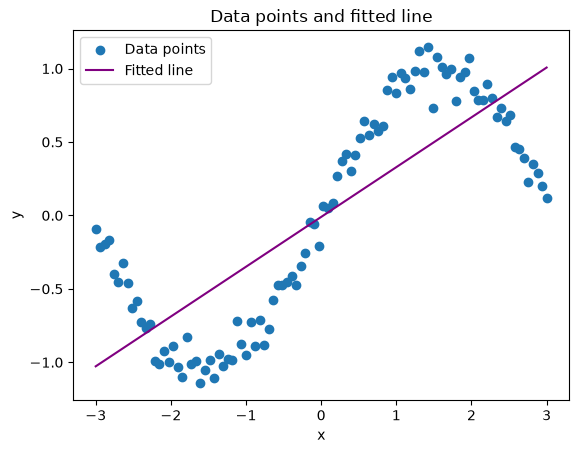

In [15]:
# Section 1: Inside a Neural Network

# Generatex values
x = np.linspace(-3, 3, 100)

# Generate random noise
noise = np.random.normal(0, 0.1, 100)

# Generate y values + noise
y = np.sin(x) + noise

# plotting
plt.scatter(x, y, label="Data points")
plt.title("Generated Data")
plt.show()

# Initializing the weight and bias
w = np.random.randn() * 0.01
b = np.random.randn() * 0.01

# Implementing one gradient descent step
lr = 0.01
losses = []


for step in range(200):
    y_hat = w * x + b
    loss = np.mean((y_hat - y) ** 2)  # Mean squared error
    losses.append(loss)

    # Calculating gradients
    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))

    # Updating weights and bias
    w = w - lr * dw
    b = b - lr * db

# Plotting the loss curve over 200 steps
plt.plot(losses)
plt.title("Loss over iterations")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

# Plotting the data with the fitted line top
y_hat = w * x + b
plt.scatter(x, y, label="Data points")
plt.plot(x, y_hat, color="purple", label="Fitted line")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Data points and fitted line")
plt.legend()
plt.show()


Student Reasoning
1.Refer to the picture below
2.This is underfitting because the loss stops decreasing at a point while the fitted line does not match the sine wave. A single neuron can only learn a linear relationship if it does not have any linear layers so no amount of training can make a straight line fit accurately

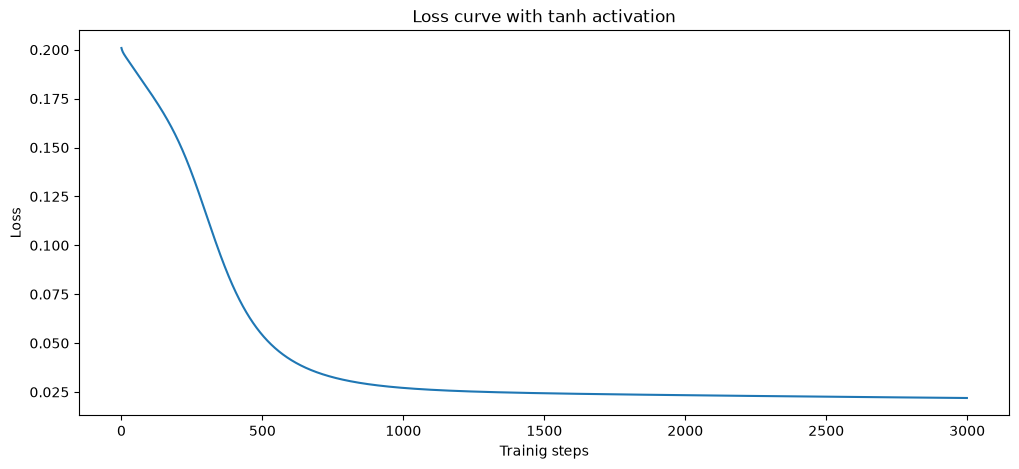

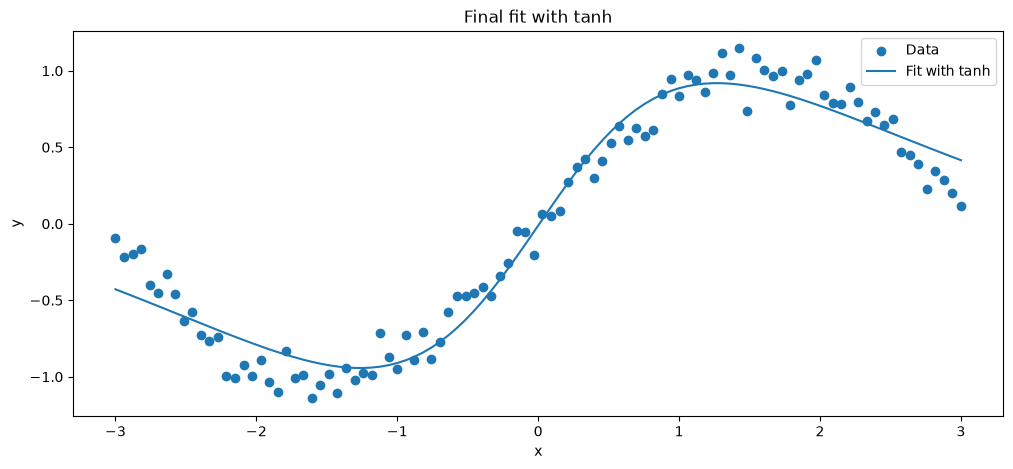

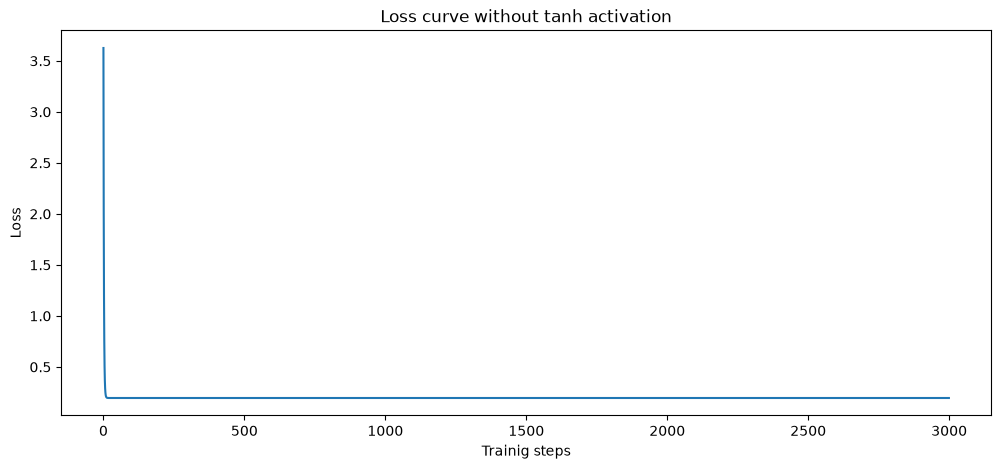

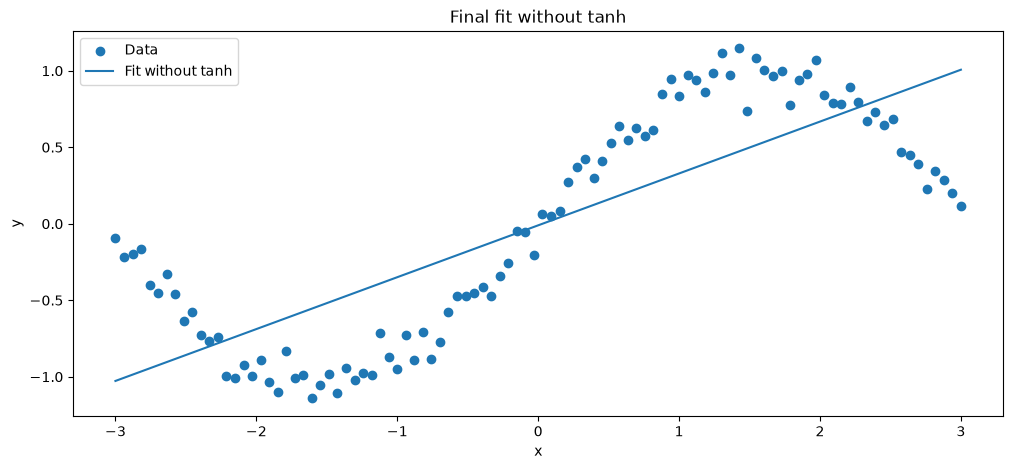

In [16]:
# Hidden layers and activations

# Reshaping x and y
x = x.reshape(-1,1)
y=y.reshape(-1,1)

# Initializing the weights and biases
W1 = np.random.randn(1,8) * 0.5
b1 = np.zeros(8)

W2 = np.random.randn(8,1) * 0.5
b2 = np.zeros(1)

lr = 0.01
steps = 3000
losses = []

# Forward pass
z1 = x @ W1 + b1
h = np.tanh(z1)
y_hat = h @ W2 + b2
loss = np.mean((y_hat - y)  ** 2)

# Backward pass
d_yhat = 2 * (y_hat -y) / len(y)
dW2 = h.T @ d_yhat
db2 = d_yhat.sum(axis = 0)
dh = d_yhat @ W2.T
dz1 = dh * (1 - np.tanh(z1) ** 2)
dW1 = x.T @ dz1
db1 = dz1.sum(axis = 0)

# Updating all parameters
for step in range(steps):
    # Forward pass
    z1 = x @ W1 + b1
    h = np.tanh(z1)
    y_hat = h @ W2 + b2
    loss = np.mean((y_hat - y)  ** 2)
    losses.append(loss)

    # Backward pass
    d_yhat = 2 * (y_hat -y) / len(y)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis = 0)
    dh = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)
    dW1 = x.T @ dz1
    db1 = dz1.sum(axis = 0)

    # Updating the parameters
    W1 -= lr * dW1
    b1 -= lr * db1

    W2 -= lr * dW2
    b2 -= lr * db2

# Plotting the loss curve and final fit over the data
plt.figure(figsize=(12, 5))
plt.plot(losses)
plt.title("Loss curve with tanh activation")
plt.xlabel("Trainig steps")
plt.ylabel("Loss")
plt.show()

plt.figure(figsize=(12, 5))
plt.scatter(x, y, label="Data")
plt.plot(x, y_hat, label="Fit with tanh")
plt.title("Final fit with tanh")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()


# Re-run without non linear activation
W1_linear = np.random.randn(1, 8) * 0.5
b1_linear = np.zeros(8)

W2_linear = np.random.randn(8, 1) * 0.5
b2_linear = np.zeros(1)

linear_losses = []

for step in range(3000):

    # Forward pass without tanh
    z1 = x @ W1_linear + b1_linear
    h = z1
    y_hat_linear = h @ W2_linear + b2_linear

    loss = np.mean((y_hat_linear - y) ** 2)
    linear_losses.append(loss)

    # Backward pass
    d_yhat = 2 * (y_hat_linear - y) / len(y)

    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)

    dh = d_yhat @ W2_linear.T

    # No tanh, so derivative is 1
    dz1 = dh

    dW1 = x.T @ dz1
    db1 = dz1.sum(axis=0)

    # Update parameters
    W1_linear -= lr * dW1
    b1_linear -= lr * db1
    W2_linear -= lr * dW2
    b2_linear -= lr * db2

# Plotting the loss curve and final fit over the data
plt.figure(figsize=(12, 5))
plt.plot(linear_losses)
plt.title("Loss curve without tanh activation")
plt.xlabel("Trainig steps")
plt.ylabel("Loss")
plt.show()

plt.figure(figsize=(12, 5))
plt.scatter(x, y, label="Data")
plt.plot(x, y_hat_linear, label="Fit without tanh")
plt.title("Final fit without tanh")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

# Observation: With the tanh activation function , the network was able to learn the no linear sine wave pattern and produced a curved fit which almost matched the data but when the tanh activation was removed, the network produced a straight line fit which did not match the data at all.This shows that non linear activation functions are important because without them multiple layers are equal to a single linear model.





Student reasoning 
1.If one layer is y=W1x + b, and we have another layer x = W2x + b2 and we substitue x in you will get y = W1(W2x+ b2) + b1 which is still linear. Thus without tanh, multiple linear layers are mathematically the same as one linear layer so it wont be able to model non linear functions

2.The 8 hidden neurons learnt different non linear features of the input after applying the tanh activation so putting all of their outputs together helped in approximating the shape of the sine wave.

3.Back propagation is a series of steps that calculates the gradient of the loss with respect to every network parameter and uses them to update the weights during training

c:\Users\quart\OneDrive\Documents\School\2nd year semester 2\Intro to AI\lab-3\.venv\Lib\site-packages\numpy\_core\_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
C:\Users\quart\AppData\Local\Temp\ipykernel_7208\3753465697.py:14: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - y) ** 2)
c:\Users\quart\OneDrive\Documents\School\2nd year semester 2\Intro to AI\lab-3\.venv\Lib\site-packages\numpy\_core\_methods.py:132: RuntimeWarning: invalid value encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
C:\Users\quart\AppData\Local\Temp\ipykernel_7208\3753465697.py:22: RuntimeWarning: invalid value encountered in scalar subtract
  w -= lr * dw


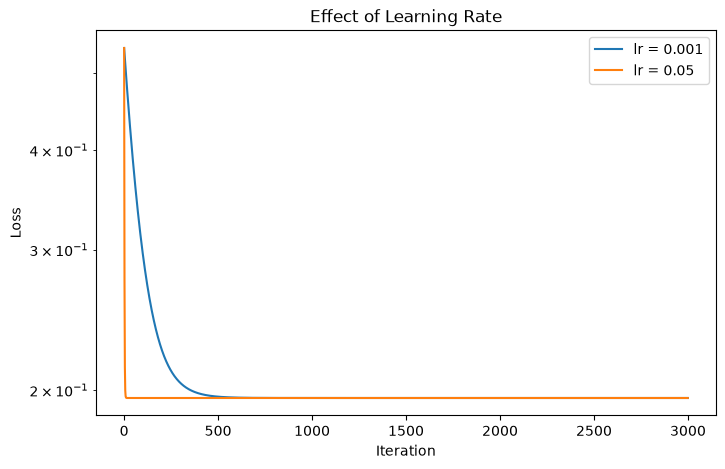

In [17]:
# Part 1.3- The learning rate
def train_toy(lr, steps=3000):
    np.random.seed(RANDOM_STATE)   

    # Initialize weights
    w = np.random.randn() * 0.01
    b = np.random.randn() * 0.01

    losses = []

    for step in range(steps):
        # Forward pass
        y_hat = w * x + b
        loss = np.mean((y_hat - y) ** 2)
        losses.append(loss)

        # Gradients
        dw = np.mean(2 * (y_hat - y) * x)
        db = np.mean(2 * (y_hat - y))

        # Gradient descent update
        w -= lr * dw
        b -= lr * db

    return losses

loss_lr1 = train_toy(0.001)
loss_lr2 = train_toy(0.05)
loss_lr3 = train_toy(1.0)

plt.figure(figsize=(8,5))

plt.plot(loss_lr1, label="lr = 0.001")
plt.plot(loss_lr2, label="lr = 0.05")
# plt.plot(loss_lr3, label="lr = 1.0")

plt.yscale("log")      
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Effect of Learning Rate")
plt.legend()
plt.show()

Student reasoning
The 0.001 learning rate converges slowly, the 0.005 converges much faster but the 1.0 rate diverges because the upadates are too large.

In [18]:
# Section 2.1- Preprocess and split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import OrdinalEncoder

# Loading the dataset
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
obesity = pd.read_csv(OBESITY_URL)

# Encoding categorical variables
binary_cols = ["family_history_with_overweight","FAVC","SMOKE","SCC"]
for col in binary_cols:
    obesity[col] = obesity[col].map({"yes" : 1,"no": 0})

# Encoding Gender
obesity["Gender"]= obesity["Gender"].map({"Female": 0, "Male": 1})

# Encoding CAEC and CALC
ordinal_cols = ["CAEC", "CALC"]
encoder = OrdinalEncoder()
obesity[ordinal_cols] = encoder.fit_transform(obesity[ordinal_cols])

# Encoding MTRANS
obesity = pd.get_dummies(obesity, columns = ["MTRANS"], drop_first = True)

# Encoding the target variable
label_e = LabelEncoder()
obesity["NObeyesdad"]= label_e.fit_transform(obesity["NObeyesdad"])

# Splitting the dataset into features and target variable
X = obesity.drop("NObeyesdad", axis=1)
y = obesity["NObeyesdad"]

# 60/20/20 split for training, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size = 0.4, stratify = y, random_state = RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size = 0.5, stratify = y_temp, random_state = RANDOM_STATE)


# Scaling the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Converting to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

# Creating DataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = 32, shuffle = False)
test_loader = DataLoader(test_dataset, batch_size = 32, shuffle = False)



Student Reasoning
1.This is because it uses the integers to directly choose the correct class probability from the model's output making the calculation more efficient
2.Gradient descent is used to update the weights of the networks and they depend on the input feautures so if some inputs are very large this might cause the gradients to be also large which leads to slower learning. Thus standardizing keeps the gradient on a similar scale which leades to faster and stable training.
3.This randomly changes the order of the training sample at the start of each epoch thus preventing the model from learning patterns based on the order of the data and improving generalisation by exposing the network to different orders at each epoch.

In [19]:
# Part 2.2- Design the network
import torch.nn as nn

class FeedForwardNet(nn.Module):
    def __init__(self,input_dim, hidden_sizes=(64, 32), n_classes = 7):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_sizes[0]),
            nn.ReLU(),

            nn.Linear(hidden_sizes[0], hidden_sizes[1]),
            nn.ReLU(),

            nn.Linear(hidden_sizes[1], n_classes)
        )
    def forward(self,x):
        return self.network(x)

# Instantiating the model
input_dim = X_train_tensor.shape[1]

model = FeedForwardNet(input_dim=input_dim, hidden_sizes = (64,32), n_classes = 7).to(DEVICE)
print(model)


# Count trainable parameter
trainable_parameter = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Total trainable parameters:", trainable_parameter)

first_layer_parameter = input_dim * 64 + 64
print("First layer parameters:", first_layer_parameter)



    
    


FeedForwardNet(
  (network): Sequential(
    (0): Linear(in_features=19, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=7, bias=True)
  )
)
Total trainable parameters: 3591
First layer parameters: 1280


Student Reasoning
1.1st layer - 19x64+64=1280
  2nd layer - 64x32+32=2080
  output layer - 32x7+7
  total parameters - 1280+2080+231 = 3591

  parameters = (inputs x outputs) + outputs

2.ReLU is used because it is simpler when computing and helps reduce the vanishing gradient problem.

3.Without it the network would become a sequence of linear transformations because as shown in 1.2 multiple linear layers still produce a single linear transformation so the network would behave like a single linear model

Epoch 01/ 50 | Train Loss:  1.783989 | Val Loss: 1.8002 | Train Accuracy: 0.3523 | Val Accuracy: 0.3555
Epoch 02/ 50 | Train Loss:  1.485460 | Val Loss: 1.5218 | Train Accuracy: 0.5324 | Val Accuracy: 0.5118
Epoch 03/ 50 | Train Loss:  1.142387 | Val Loss: 1.1968 | Train Accuracy: 0.6185 | Val Accuracy: 0.5972
Epoch 04/ 50 | Train Loss:  0.908703 | Val Loss: 0.9753 | Train Accuracy: 0.6943 | Val Accuracy: 0.6801
Epoch 05/ 50 | Train Loss:  0.754260 | Val Loss: 0.8450 | Train Accuracy: 0.7338 | Val Accuracy: 0.7133
Epoch 06/ 50 | Train Loss:  0.637843 | Val Loss: 0.7540 | Train Accuracy: 0.7836 | Val Accuracy: 0.7512
Epoch 07/ 50 | Train Loss:  0.556138 | Val Loss: 0.6858 | Train Accuracy: 0.8341 | Val Accuracy: 0.7986
Epoch 08/ 50 | Train Loss:  0.491674 | Val Loss: 0.6425 | Train Accuracy: 0.8515 | Val Accuracy: 0.7986
Epoch 09/ 50 | Train Loss:  0.426697 | Val Loss: 0.5864 | Train Accuracy: 0.8720 | Val Accuracy: 0.8318
Epoch 10/ 50 | Train Loss:  0.376873 | Val Loss: 0.5521 | Train 

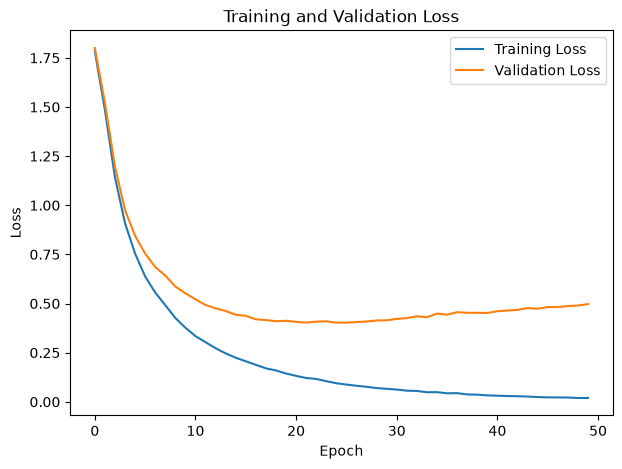

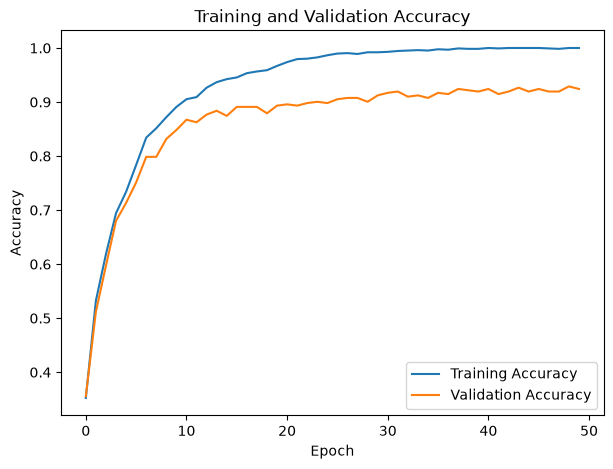

In [20]:
# Section 2.3- The training loop
import matplotlib.pyplot as plt

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3)

num_epochs = 50

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

best_val_accuracy = 0.0

for epoch in range(num_epochs):
    model.train()

    for xb, yb in train_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad()

        logits = model(xb)
        loss = criterion(logits, yb)

        loss.backward()
        optimizer.step()

    model.eval()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for xb,yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            logits = model(xb)
            loss = criterion(logits, yb)

            train_loss += loss.item() * xb.size(0)
            predictions = torch.argmax(logits, dim=1)

            train_correct += (predictions == yb).sum().item()
            train_total += yb.size(0)

        for xb,yb in val_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            logits = model(xb)
            loss = criterion(logits, yb)

            val_loss += loss.item() * xb.size(0)
            predictions = torch.argmax(logits, dim=1)

            val_correct += (predictions == yb).sum().item()
            val_total += yb.size(0)

    # Average loss and accuracy
    train_loss = train_loss / train_total
    val_loss = val_loss / val_total

    train_accuracy = train_correct / train_total
    val_accuracy = val_correct / val_total

    # Store history
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    # Saving the model
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        torch.save(model.state_dict(), "ffn_best.pt")

    # Printing epoch summary
    print(
        f"Epoch {epoch + 1:02d}/ {num_epochs} | "
        f"Train Loss: {train_loss : 4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train Accuracy: {train_accuracy:.4f} | "
        f"Val Accuracy: {val_accuracy:.4f}"
    )

# Plotting the loss curve
plt.figure(figsize=(7,5))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

# Plotting the accuracy curve
plt.figure(figsize = (7,5))

plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()


    




Student Reasoning
1.Forward pass- y_hat = w* X + b
  Computes gradient- dw = np.mean(2 * (y_hat - y) * x)
                     db = np.mean(2 * (y_hat - y))
  Update rule- w -= lr * dw
               b -= lr * db
2.The model is overfitting slightly because the training loss decreased to about 0.02 while the validation loss decreased to about 0.4 before increasing to 0.5. Though the training accuracy reached 100% , validation accuracy started dropping which shows that the model started memorizing the training data
3.It clears the gradients before each batch and without it, the gradients accumulate across batches, leading to incorrect parameter updates and unstable training.


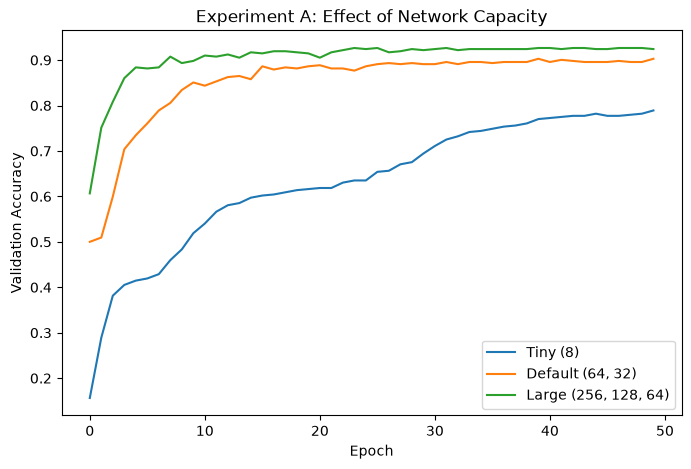

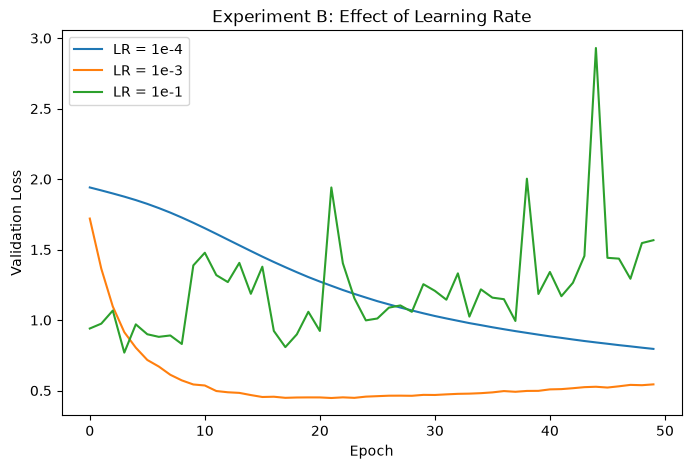

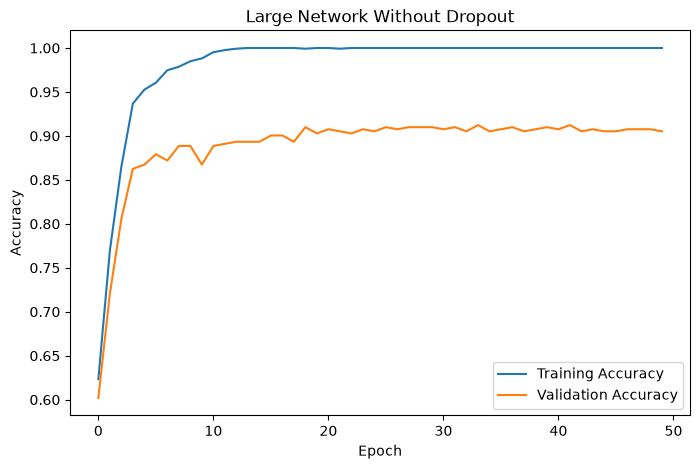

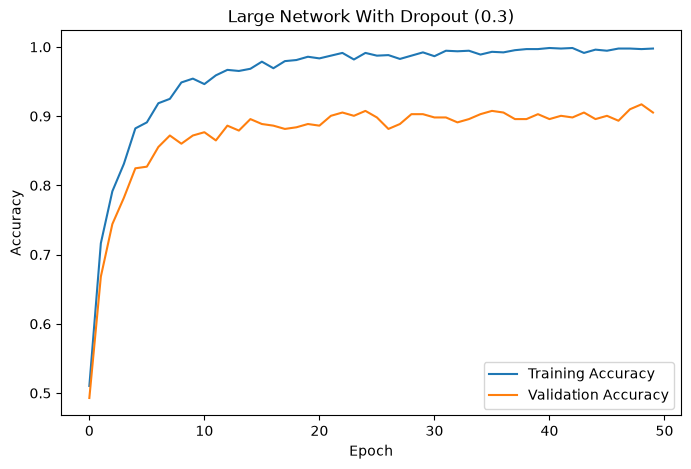

In [21]:
# Section 2.4 - Experiments

class FeedForwardNet(nn.Module):
    def __init__(
        self,
        input_dim,
        hidden_sizes=(64, 32),
        n_classes=7,
        dropout=0.0
    ):
        super().__init__()

        layers = []
        current_dim = input_dim

        for hidden_dim in hidden_sizes:
            layers.append(nn.Linear(current_dim, hidden_dim))
            layers.append(nn.ReLU())

            if dropout > 0:
                layers.append(nn.Dropout(dropout))

            current_dim = hidden_dim

        layers.append(nn.Linear(current_dim, n_classes))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


# Experiment function
def run_experiment(
    hidden_sizes=(64, 32),
    lr=1e-3,
    batch_size=32,
    epochs=50,
    dropout=0.0
):
    experiment_train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    experiment_val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    experiment_model = FeedForwardNet(
        input_dim=input_dim,
        hidden_sizes=hidden_sizes,
        n_classes=7,
        dropout=dropout
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        experiment_model.parameters(),
        lr=lr
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_accuracy": [],
        "val_accuracy": []
    }

    for epoch in range(epochs):

        # Training
        experiment_model.train()

        for xb, yb in experiment_train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()

            logits = experiment_model(xb)
            loss = criterion(logits, yb)

            loss.backward()
            optimizer.step()

        # Evaluation
        experiment_model.eval()

        train_loss = 0.0
        train_correct = 0
        train_total = 0

        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():

            # Training metrics
            for xb, yb in experiment_train_loader:
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)

                logits = experiment_model(xb)
                loss = criterion(logits, yb)

                train_loss += loss.item() * xb.size(0)

                predictions = torch.argmax(logits, dim=1)

                train_correct += (predictions == yb).sum().item()
                train_total += yb.size(0)

            # Validation metrics
            for xb, yb in experiment_val_loader:
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)

                logits = experiment_model(xb)
                loss = criterion(logits, yb)

                val_loss += loss.item() * xb.size(0)

                predictions = torch.argmax(logits, dim=1)

                val_correct += (predictions == yb).sum().item()
                val_total += yb.size(0)

        # Average metrics for this epoch
        train_loss /= train_total
        val_loss /= val_total

        train_accuracy = train_correct / train_total
        val_accuracy = val_correct / val_total

        # Store this epoch's results
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_accuracy"].append(val_accuracy)

    return history


# Experiment A

tiny_history = run_experiment(
    hidden_sizes=(8,),
    lr=1e-3,
    batch_size=32,
    epochs=50,
    dropout=0.0
)

default_history = run_experiment(
    hidden_sizes=(64, 32),
    lr=1e-3,
    batch_size=32,
    epochs=50,
    dropout=0.0
)

large_history = run_experiment(
    hidden_sizes=(256, 128, 64),
    lr=1e-3,
    batch_size=32,
    epochs=50,
    dropout=0.0
)

plt.figure(figsize=(8, 5))

plt.plot(tiny_history["val_accuracy"], label="Tiny (8)")
plt.plot(default_history["val_accuracy"], label="Default (64, 32)")
plt.plot(large_history["val_accuracy"], label="Large (256, 128, 64)")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Experiment A: Effect of Network Capacity")
plt.legend()
plt.show()


# Experiment B
# Experiment B - Learning Rate

lr_small_history = run_experiment(
    hidden_sizes=(64, 32),
    lr=1e-4,
    batch_size=32,
    epochs=50,
    dropout=0.0
)

lr_default_history = run_experiment(
    hidden_sizes=(64, 32),
    lr=1e-3,
    batch_size=32,
    epochs=50,
    dropout=0.0
)

lr_large_history = run_experiment(
    hidden_sizes=(64, 32),
    lr=1e-1,
    batch_size=32,
    epochs=50,
    dropout=0.0
)
plt.figure(figsize=(8, 5))

plt.plot(lr_small_history["val_loss"], label="LR = 1e-4")
plt.plot(lr_default_history["val_loss"], label="LR = 1e-3")
plt.plot(lr_large_history["val_loss"], label="LR = 1e-1")

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Experiment B: Effect of Learning Rate")
plt.legend()
plt.show()

# Experiment C
# Experiment C - Dropout

large_no_dropout = run_experiment(
    hidden_sizes=(256, 128, 64),
    lr=1e-3,
    batch_size=32,
    epochs=50,
    dropout=0.0
)

large_with_dropout = run_experiment(
    hidden_sizes=(256, 128, 64),
    lr=1e-3,
    batch_size=32,
    epochs=50,
    dropout=0.3
)

# Wihtout drop out
plt.figure(figsize=(8, 5))

plt.plot(
    large_no_dropout["train_accuracy"],
    label="Training Accuracy"
)

plt.plot(
    large_no_dropout["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Large Network Without Dropout")
plt.legend()
plt.show()

# With drop out
plt.figure(figsize=(8, 5))

plt.plot(
    large_with_dropout["train_accuracy"],
    label="Training Accuracy"
)

plt.plot(
    large_with_dropout["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Large Network With Dropout (0.3)")
plt.legend()
plt.show()


Student Reasoning
1.Yes the large network achieved the highest validation accuracy
2.Yes the small learning rate learnt slowly, the moderate learning rate converged best and the large learning rate was unstable
3.Dropout slightly reduced the gap between training and validation and improved generalization. It works by randomly turning off afraction of the neurons in each forward pass which prevents the model from relying on any single neuron

Test Accuracy: 0.9219858156028369
Test Macro-F1: 0.9203190514790424
                     precision    recall  f1-score   support

Insufficient_Weight     0.9796    0.8889    0.9320        54
      Normal_Weight     0.7500    0.8276    0.7869        58
     Obesity_Type_I     0.9853    0.9571    0.9710        70
    Obesity_Type_II     1.0000    0.9500    0.9744        60
   Obesity_Type_III     0.9848    1.0000    0.9924        65
 Overweight_Level_I     0.8276    0.8276    0.8276        58
Overweight_Level_II     0.9344    0.9828    0.9580        58

           accuracy                         0.9220       423
          macro avg     0.9231    0.9191    0.9203       423
       weighted avg     0.9257    0.9220    0.9231       423



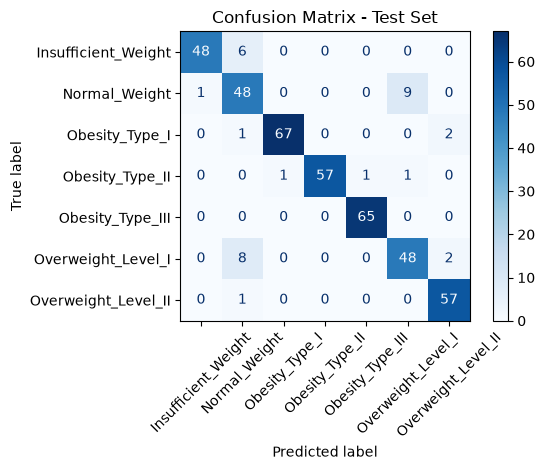

,Model,Test Accuracy,Test Macro-F1,Training Time (s),Parameters / Trees
0,Logistic Regression,0.888889,0.883878,Not recorded,140
1,Feedforward Neural Network,0.921986,0.920319,Not recorded,3591


In [22]:
# Part 2.5- Final Evaluation and showdown with Lab 2
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

best_model = FeedForwardNet(
    input_dim=input_dim,
    hidden_sizes=(64, 32),
    n_classes=7,
    dropout=0.0
).to(DEVICE)

best_model.load_state_dict(
    torch.load(
        "ffn_best.pt",
        map_location=DEVICE
    )
)

best_model.eval()

test_predictions = []
test_targets = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        logits = best_model(xb)
        predictions = torch.argmax(logits, dim=1)

        test_predictions.extend(
            predictions.cpu().numpy()
        )

        test_targets.extend(
            yb.cpu().numpy()
        )

test_predictions = np.array(test_predictions)
test_targets = np.array(test_targets)

test_accuracy = accuracy_score(
    test_targets,
    test_predictions
)

test_macro_f1 = f1_score(
    test_targets,
    test_predictions,
    average="macro"
)

print("Test Accuracy:", test_accuracy)
print("Test Macro-F1:", test_macro_f1)

class_names = label_e.classes_

print(
    classification_report(
        test_targets,
        test_predictions,
        target_names=class_names,
        digits=4
    )
)

from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(
    test_targets,
    test_predictions,
    display_labels=label_e.classes_,
    xticks_rotation=45,
    cmap="Blues"
)

plt.title("Confusion Matrix - Test Set")
plt.tight_layout()
plt.show()


nn_parameters = sum(
    p.numel()
    for p in best_model.parameters()
    if p.requires_grad
)
logistic_parameters = len(label_e.classes_) * (X_train.shape[1] + 1)
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Feedforward Neural Network"
    ],
    "Test Accuracy": [
        0.8888888888888888,
        test_accuracy
    ],
    "Test Macro-F1": [
        0.8838779799778422,
        test_macro_f1
    ],
    "Training Time (s)": [
        "Not recorded",
        "Not recorded"
    ],
    "Parameters / Trees": [
        logistic_parameters,
        nn_parameters
    ]
})
comparison


Student Reasoning
1.The network confuses Normal Weight and Overweight level 1 and yes it is the same one the Lab 2 classifier confused
2.The neural network performed slightly better than the classical model. Since the improvement was minimal the extra effort of deep learning was not really justified. It would be worth it with larger datasets or problems with more complex non linear relationships

Section 3- Reflection
1.loss.backward()- The gradients are calculated the back propagation is used to calculate how much each weight and bias contributed to the loss

-The gradients are stored for each parameter which tells the optimizer which direction will reduce the loss

optimizer.step()- This updates the parameters and uses the stored gradients as well as the learning rate to adjust the weight and biases.

2.I would pick the learning rate because it has the biggest impact on training. If the rate is too high the model may not converge but if its too low training would be very slow so choosing a good learning rate helps the model learn efficiently and improves the model's performance

3.The biggest gap occured with the larger network and the intervention which reduced the gap the most was using dropout.

4.A plain MLP might struggle because it would disregard the relationships between nearby pixels and a better architecture should be able to capture local patterns and spatial information like a CNN